1. How many Movies and TV Shows are available?
2. Which country produces the most content?
3. Which years had the highest releases?
4. What are the most common genres?
5. What trends can be observed in Netflix content?

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [99]:
df.shape

(8807, 12)

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [101]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [102]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [103]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

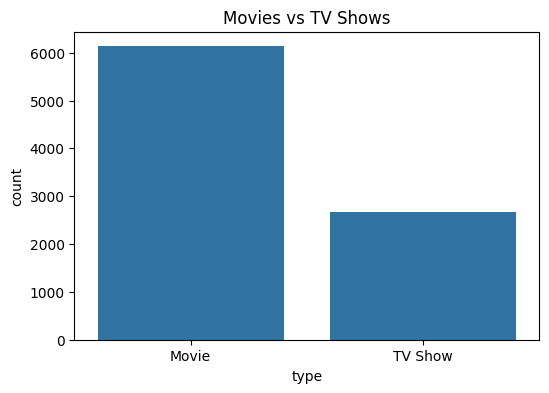

In [104]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="type")
plt.title("Movies vs TV Shows")
plt.show()

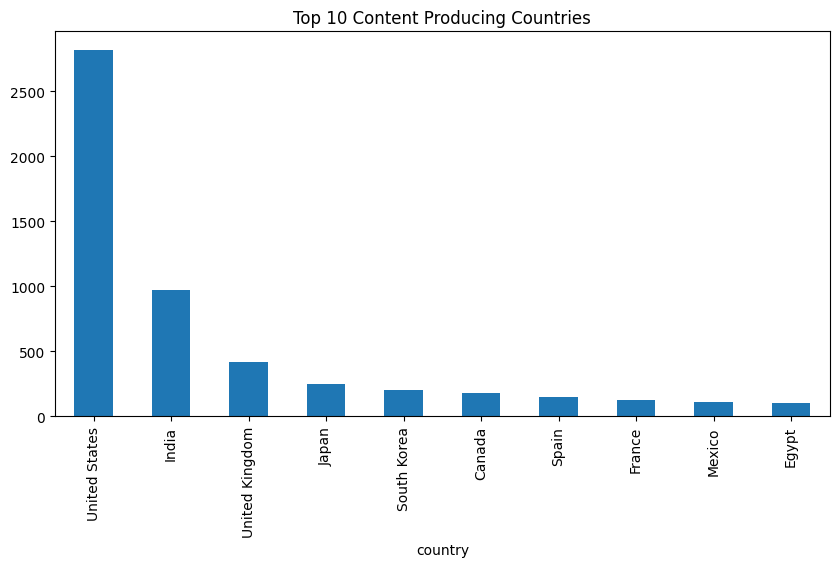

In [105]:
country_count=df["country"].value_counts().head(10)

plt.figure(figsize=(10,5))
country_count.plot(kind="bar")
plt.title("Top 10 Content Producing Countries")
plt.show()

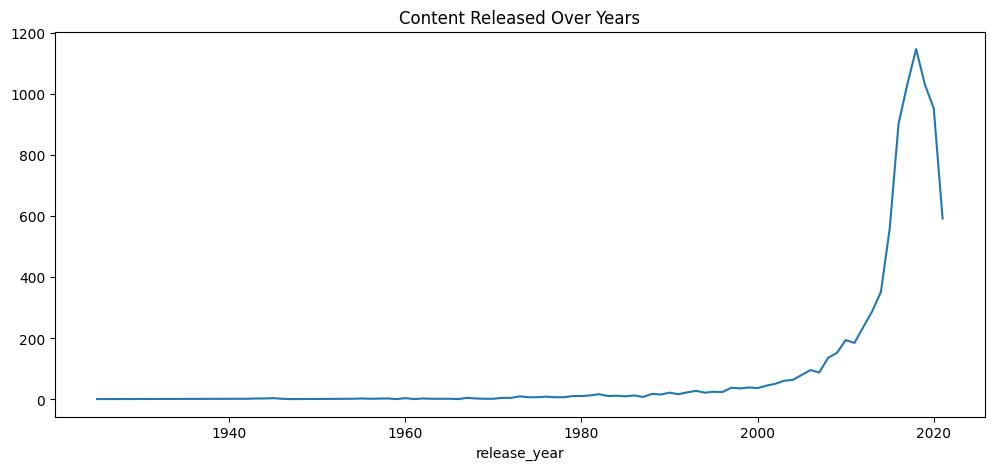

In [106]:
release_year_count=df["release_year"].value_counts().sort_index()

plt.figure(figsize=(12,5))
release_year_count.plot()
plt.title("Content Released Over Years")
plt.show()

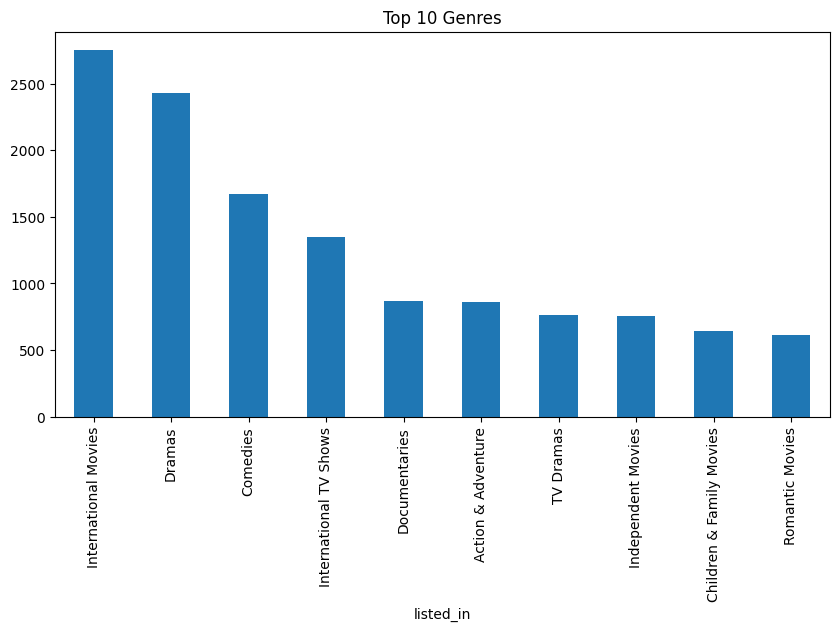

In [107]:
top_genres=df["listed_in"].str.split(", ").explode().value_counts().head(10)

plt.figure(figsize=(10,5))
top_genres.plot(kind="bar")
plt.title("Top 10 Genres")
plt.show()

In [108]:
movie_df=df[df["type"]=="Movie"]

movie_df["duration"]=movie_df["duration"].str.replace(" min","")

movie_df["duration"]=pd.to_numeric(movie_df["duration"],errors="coerce")

movie_df["duration"].describe()

C:\Users\admin\AppData\Local\Temp\ipykernel_11468\3773623182.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movie_df["duration"]=movie_df["duration"].str.replace(" min","")
C:\Users\admin\AppData\Local\Temp\ipykernel_11468\3773623182.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movie_df["duration"]=pd.to_numeric(movie_df["duration"],errors="coerce")


count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration, dtype: float64

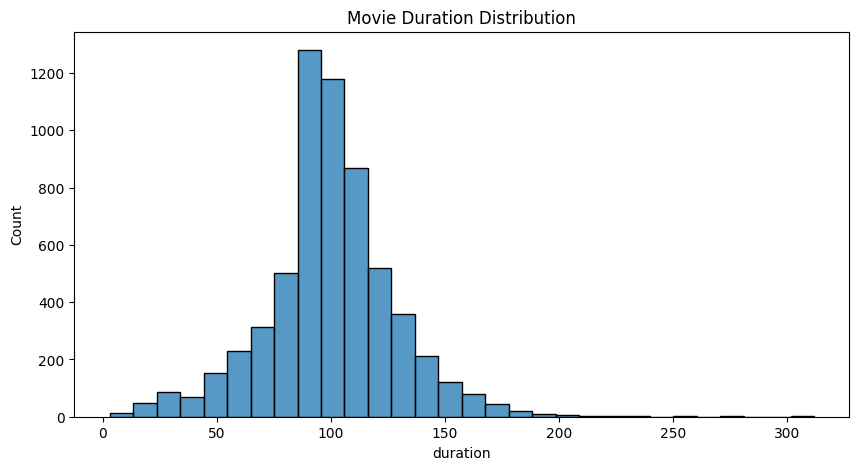

In [109]:
plt.figure(figsize=(10,5))
sns.histplot(movie_df["duration"],bins=30)
plt.title("Movie Duration Distribution")
plt.show()

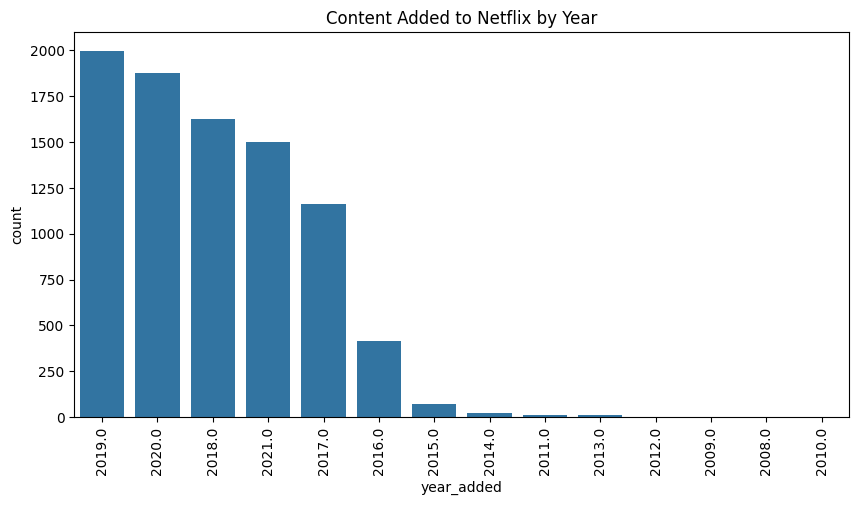

In [110]:
df["date_added"]=pd.to_datetime(df["date_added"],errors="coerce")

df["year_added"]=df["date_added"].dt.year

plt.figure(figsize=(10,5))
sns.countplot(data=df,x="year_added",order=df["year_added"].value_counts().index)
plt.xticks(rotation=90)
plt.title("Content Added to Netflix by Year")
plt.show()

Final Insights :
1. Movies significantly outnumber TV Shows.
2. United States produces the highest amount of Netflix content.
3. Netflix content increased rapidly after 2015.
4. International Movies and Dramas are among the most common genres.
5. Most movies have durations between 80 and 120 minutes.
6. Netflix expanded its content library aggressively between 2017 and 2020.